# Autoencoder

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F

from utils.train import train
from utils.scheduler import exponential_decay
from utils.data_processor import create_flower_dataloaders, show_recover_results

In [ ]:
# Set seeds
torch.manual_seed(0)
np.random.seed(0)

data_root = "../../Data/flowers"
model_save_root = "../../Models/AE"

batch_size = 16
img_width, img_height = 24, 24

training_dataloader, validation_dataloader = create_flower_dataloaders(batch_size, data_root, img_width, img_height)
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

## MLP Autoencoder

#### Train

In [4]:
from MLPAE import MLPAutoencoder, MLPAE_ENCODING_DIM

num_epochs = 100
early_stopping_patience = 5
lr = 1.

model = MLPAutoencoder(MLPAE_ENCODING_DIM, img_width, img_height)
loss_fn = F.mse_loss

optimizer = optim.SGD(
    model.parameters(), 
    momentum=0., 
    lr=lr
) 
scheduler = exponential_decay(
    initial_learning_rate=lr, 
    decay_rate=0.9, 
    decay_epochs=10
) 

model.to(device)

# Start training
train(
    optimizer=optimizer,
    scheduler=scheduler,
    model=model,
    training_dataloader=training_dataloader,
    validation_dataloader=validation_dataloader,
    num_epochs=num_epochs,
    early_stopping_patience=early_stopping_patience,
    device=device,
    model_save_root=model_save_root,
    loss_fn=loss_fn,
)

Model saved at epoch 0, val_loss=0.078642
Epoch: 0, Train Loss: 0.08089493848383426, Valid Loss: 0.07864188583511295
Epoch: 1, Train Loss: 0.07995381833842168, Valid Loss: 0.07864188583511295
Epoch: 2, Train Loss: 0.07850466018112806, Valid Loss: 0.07864188583511295
Model saved at epoch 3, val_loss=0.059498
Epoch: 3, Train Loss: 0.07070017319459182, Valid Loss: 0.059497514005863304
Epoch: 4, Train Loss: 0.05274572968482971, Valid Loss: 0.059497514005863304
Epoch: 5, Train Loss: 0.04700525185236564, Valid Loss: 0.059497514005863304
Model saved at epoch 6, val_loss=0.044181
Epoch: 6, Train Loss: 0.04586254204981602, Valid Loss: 0.04418145549116713
Epoch: 7, Train Loss: 0.044981957599520686, Valid Loss: 0.04418145549116713
Epoch: 8, Train Loss: 0.04432444641223321, Valid Loss: 0.04418145549116713
Model saved at epoch 9, val_loss=0.040897
Epoch: 9, Train Loss: 0.0434463372024206, Valid Loss: 0.04089690694077448
Epoch: 10, Train Loss: 0.042735266055052096, Valid Loss: 0.04089690694077448
Ep

#### Visualization

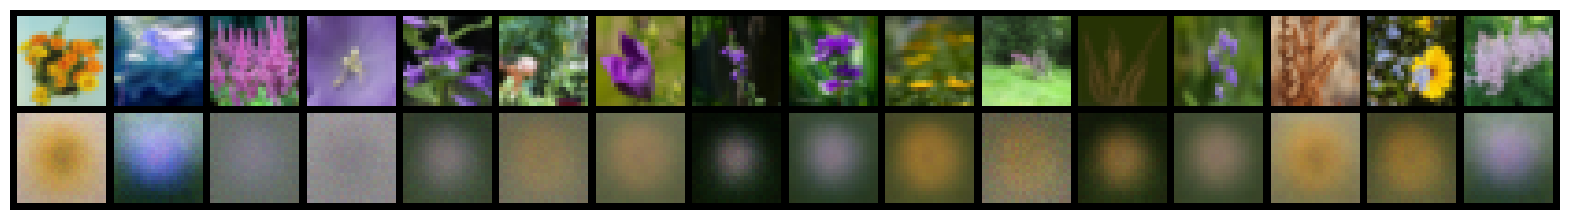

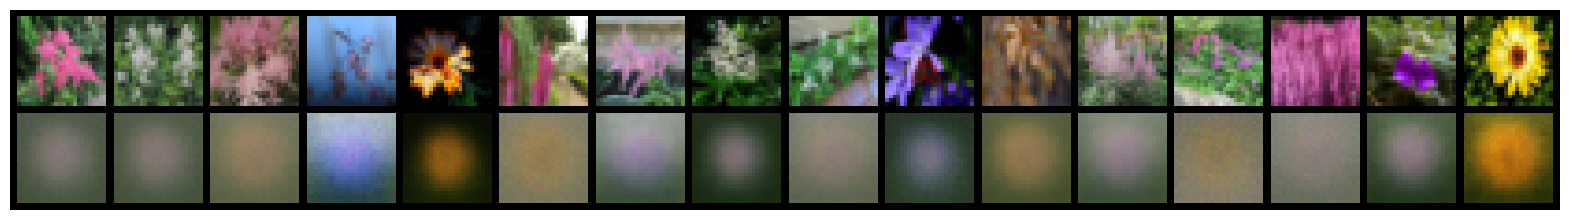

In [ ]:
# vis
model_ckpt = os.path.join(model_save_root,f"Best_{model.name}.pth")

model = MLPAutoencoder(MLPAE_ENCODING_DIM, img_width, img_height)
model.load_state_dict(torch.load(model_ckpt))
model.eval()
model.to(device)

# visualize the results
train_images_sampled = next(iter(training_dataloader))[0].to(device)
valid_images_sampled = next(iter(validation_dataloader))[0].to(device)

train_outputs = model(train_images_sampled)
valid_outputs = model(valid_images_sampled)

show_recover_results(train_images_sampled, train_outputs)
show_recover_results(valid_images_sampled, valid_outputs)

## CNN Autoencoder

#### Train

In [6]:
from CNNAE import CNNAutoencoder, CNNAE_ENCODING_DIM

num_epochs = 30   
early_stopping_patience = 5
lr = 1e-3

model = CNNAutoencoder(CNNAE_ENCODING_DIM) 
loss_fn = F.mse_loss

optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    betas=(0.9, 0.999),
    weight_decay=1e-5
)
scheduler = exponential_decay(
    initial_learning_rate=lr,
    decay_rate=0.8,      
    decay_epochs=5       
)

model.to(device)

# Start training
train(
    optimizer=optimizer,
    scheduler=scheduler,
    model=model,
    training_dataloader=training_dataloader,
    validation_dataloader=validation_dataloader,
    num_epochs=num_epochs,
    early_stopping_patience=early_stopping_patience,
    device=device,
    model_save_root=model_save_root,
    loss_fn=loss_fn,
)

Model saved at epoch 0, val_loss=0.029553
Epoch: 0, Train Loss: 0.043823281933481874, Valid Loss: 0.029552636555198467
Epoch: 1, Train Loss: 0.025285901731023422, Valid Loss: 0.029552636555198467


Epoch: 2, Train Loss: 0.019993926606212672, Valid Loss: 0.029552636555198467
Model saved at epoch 3, val_loss=0.015819
Epoch: 3, Train Loss: 0.01685291765830838, Valid Loss: 0.015818951707897766
Epoch: 4, Train Loss: 0.015248604254940382, Valid Loss: 0.015818951707897766
Epoch: 5, Train Loss: 0.013978893546244273, Valid Loss: 0.015818951707897766
Model saved at epoch 6, val_loss=0.012488
Epoch: 6, Train Loss: 0.012919158560152237, Valid Loss: 0.012488019398667595
Epoch: 7, Train Loss: 0.0120240714150266, Valid Loss: 0.012488019398667595
Epoch: 8, Train Loss: 0.011421165565172068, Valid Loss: 0.012488019398667595
Model saved at epoch 9, val_loss=0.011074
Epoch: 9, Train Loss: 0.010968438098923517, Valid Loss: 0.011073666427171591
Epoch: 10, Train Loss: 0.01037805826904682, Valid Loss: 0.011073666427171591
Epoch: 11, Train Loss: 0.010136302549821827, Valid Loss: 0.011073666427171591
Model saved at epoch 12, val_loss=0.010336
Epoch: 12, Train Loss: 0.009974429240593543, Valid Loss: 0.0103

#### Visualization

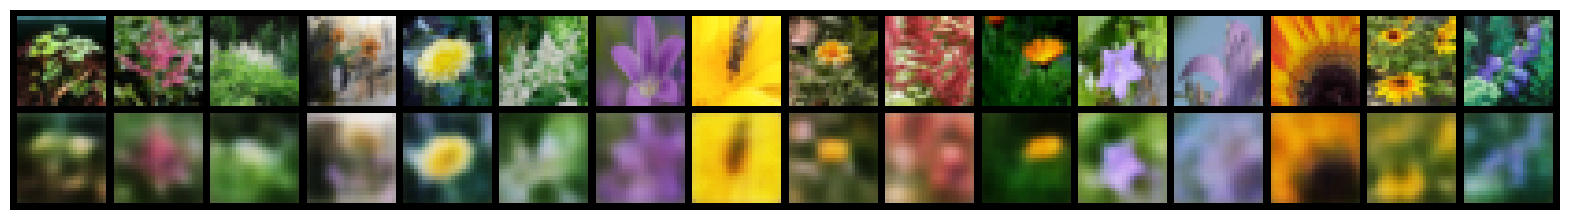

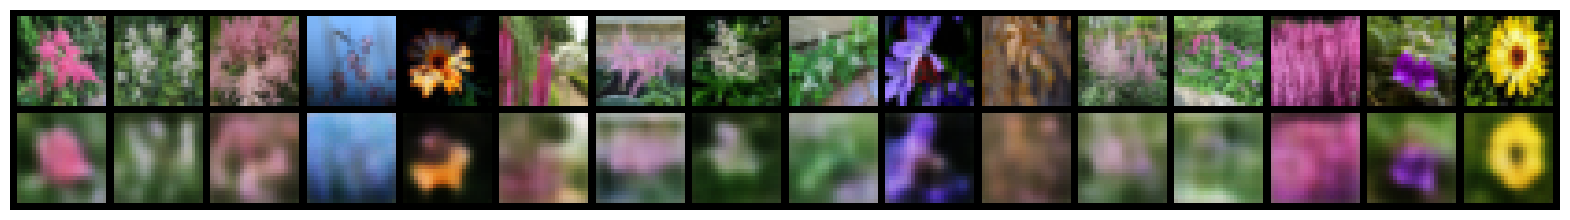

In [ ]:
# vis
model_ckpt = os.path.join(model_save_root,f"Best_{model.name}.pth")

model = CNNAutoencoder(CNNAE_ENCODING_DIM) 
model.load_state_dict(torch.load(model_ckpt))
model.eval()
model.to(device)

# visualize the results
train_images_sampled = next(iter(training_dataloader))[0].to(device)
valid_images_sampled = next(iter(validation_dataloader))[0].to(device)

train_outputs = model(train_images_sampled)
valid_outputs = model(valid_images_sampled)

show_recover_results(train_images_sampled, train_outputs)
show_recover_results(valid_images_sampled, valid_outputs)

#### Random sample

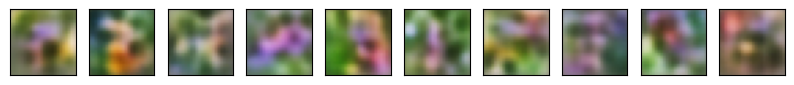

In [ ]:
model_save_path = os.path.join(model_save_root,f"Best_{model.name}.pth")

model = CNNAutoencoder(CNNAE_ENCODING_DIM) 
model.load_state_dict(torch.load(model_save_path))
model.eval()

with torch.no_grad():
    z = torch.randn(10, CNNAE_ENCODING_DIM)
    random_images = model.decoder(z)
    random_images = torch.clamp(random_images, 0.0, 1.0)

fig = plt.figure(figsize=(10, 1))

for i in range(10):
    ax = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
    ax.imshow(np.transpose(random_images[i].detach().numpy(), (1, 2, 0)))